## Lab 5 - Word Embeddings: Word2Vec

Here we will train some word embeddings with gensim and analyse the resulting representations. 

In [1]:
! pip install gensim scikit-learn matplotlib numpy

   ---------------------------------------- 24.4/24.4 MB 7.2 MB/s  0:00:03



In [2]:
from gensim.test.utils import common_texts
from sklearn.decomposition import PCA
from gensim.models import Word2Vec
import gensim.downloader as api
import matplotlib.pyplot as plt
import numpy as np

### Word2Vec using Google news dataset
This Word2Vec model uses an embedding size of 300

In [3]:
word2vec_gn= api.load('word2vec-google-news-300')

[==================================================] 100.0% 1662.8/1662.8MB downloaded


In [24]:
chocolate = word2vec_gn['chocolate'] 
tea = word2vec_gn['tea'] 
coffee = word2vec_gn['coffee']  

car = word2vec_gn['car'] 
Trunk = word2vec_gn['Trunk'] 
elephant= word2vec_gn['elephant'] 
vehicle = word2vec_gn['vehicle']  

print(word2vec_gn.most_similar("car", topn=10))

[('vehicle', 0.7821096181869507), ('cars', 0.7423831224441528), ('SUV', 0.7160962224006653), ('minivan', 0.6907036900520325), ('truck', 0.6735789775848389), ('Car', 0.6677608489990234), ('Ford_Focus', 0.667320191860199), ('Honda_Civic', 0.6626849174499512), ('Jeep', 0.651133120059967), ('pickup_truck', 0.6441438794136047)]


In [20]:
cTve = np.array([car,Trunk,vehicle,elephant])
cTve.shape

(4, 300)

In [21]:
pca = PCA(n_components=2, svd_solver='full')
pcs= pca.fit_transform(cTve)
pcs

array([[-0.7239406 ,  1.3609358 ],
       [-1.2216848 , -2.418871  ],
       [-0.93203723,  1.3161768 ],
       [ 2.8776636 , -0.25824237]], dtype=float32)

In [15]:
pcs_X = pcs[:, 0]
pcs_X 

array([-0.7239406 , -1.2216848 , -0.93203723,  2.8776636 ], dtype=float32)

In [16]:
pcs_Y = pcs[:, 1]
pcs_Y 

array([ 1.3609358 , -2.418871  ,  1.3161768 , -0.25824237], dtype=float32)

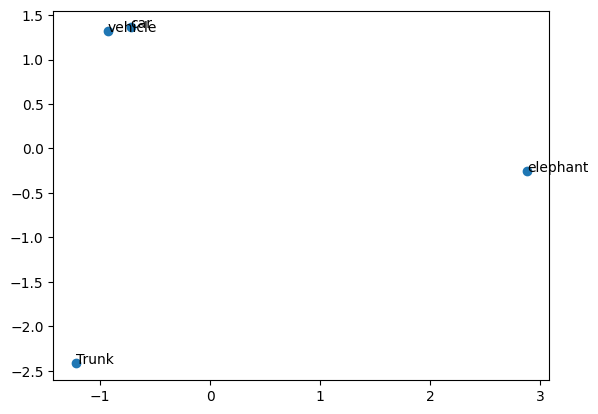

In [17]:
fig, ax = plt.subplots()
ax.scatter(pcs_X, pcs_Y)
words = ["car","Trunk","vehicle", "elephant"]
for i, word in enumerate(words):
    ax.annotate(word, (pcs_X[i], pcs_Y[i]))
plt.show()

### Word2Vec using the [Text8](https://mattmahoney.net/dc/textdata.html) dataset
This Word2Vec model uses an embedding size of 300

In [10]:
text8_dataset = api.load("text8")  
word2vec_ct= Word2Vec(text8_dataset, vector_size=300, window=5, min_count=1, workers=4)

[==================================================] 100.0% 31.6/31.6MB downloaded


In [27]:
# Get the top 10 most similar words to "car"
word2vec_ct.wv.most_similar('car', topn=10)


[('driver', 0.7691512107849121),
 ('cars', 0.7231881618499756),
 ('motorcycle', 0.708249032497406),
 ('vehicle', 0.6988807320594788),
 ('taxi', 0.6738329529762268),
 ('truck', 0.6698072552680969),
 ('glider', 0.665684163570404),
 ('passenger', 0.6629154682159424),
 ('racing', 0.6380500197410583),
 ('bicycle', 0.6296926736831665)]